In [1]:
import geopandas as gpd
import pandas as pd

# Load the Brisbane flood risk layer (this is large — be patient)
flood = gpd.read_file("../data/raw/flood_risk_overall.geojson")

print("Number of features (polygons):", len(flood))
print("CRS:", flood.crs)
print("\nColumn names:")
print(flood.columns.tolist())
print("\nFirst few rows (without geometry):")
print(flood.drop(columns="geometry").head())

Number of features (polygons): 231445
CRS: EPSG:4326

Column names:
['OBJECTID', 'FLOOD_RISK', 'FLOOD_TYPE', 'geometry']

First few rows (without geometry):
   OBJECTID FLOOD_RISK              FLOOD_TYPE
0    491699   Very Low  Creek River Storm Tide
1    491700     Medium  Creek River Storm Tide
2    491701   Very Low  Creek River Storm Tide
3    491702   Very Low  Creek River Storm Tide
4    491703        Low  Creek River Storm Tide


In [2]:
# How many polygons fall in each risk category?
print("Flood risk categories:")
print(flood["FLOOD_RISK"].value_counts())

print("\nFlood type values:")
print(flood["FLOOD_TYPE"].value_counts())

Flood risk categories:
FLOOD_RISK
Low         99887
Very Low    62601
Medium      60063
High         8894
Name: count, dtype: int64

Flood type values:
FLOOD_TYPE
Creek River Storm Tide    231445
Name: count, dtype: int64


In [3]:
# Drop the columns we don't need
flood = flood[["FLOOD_RISK", "geometry"]].copy()

# Reproject to a metric CRS (GDA2020 / MGA Zone 56, metres) so simplify tolerance is in metres
flood = flood.to_crs("EPSG:7856")

# Simplify geometry: collapse vertices within 10 metres of each other.
# This dramatically cuts file size while keeping the shapes recognisable.
flood["geometry"] = flood.geometry.simplify(10, preserve_topology=True)

print("Columns now:", flood.columns.tolist())
print("CRS now:", flood.crs)
print("Features (still):", len(flood))
print("Simplify done — ready to dissolve.")

Columns now: ['FLOOD_RISK', 'geometry']
CRS now: EPSG:7856
Features (still): 231445
Simplify done — ready to dissolve.


In [5]:
# Repair any invalid geometries (slivers/self-intersections) before dissolving
flood["geometry"] = flood.geometry.make_valid()

# Now merge all polygons of the same risk level into one shape each
flood_dissolved = flood.dissolve(by="FLOOD_RISK", as_index=False)

print("Features after dissolve:", len(flood_dissolved))
print("\nCategories:")
print(flood_dissolved["FLOOD_RISK"].tolist())

mem_mb = flood_dissolved.memory_usage(deep=True).sum() / 1024**2
print(f"\nIn-memory size: {mem_mb:.1f} MB")

Features after dissolve: 4

Categories:
['High', 'Low', 'Medium', 'Very Low']

In-memory size: 0.0 MB


/var/folders/nc/kql9kdyn21g70cyyl5qh4_400000gn/T/ipykernel_46392/1442984612.py:14: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(title="Flood likelihood", loc="upper right")
/var/folders/nc/kql9kdyn21g70cyyl5qh4_400000gn/T/ipykernel_46392/1442984612.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Flood likelihood", loc="upper right")


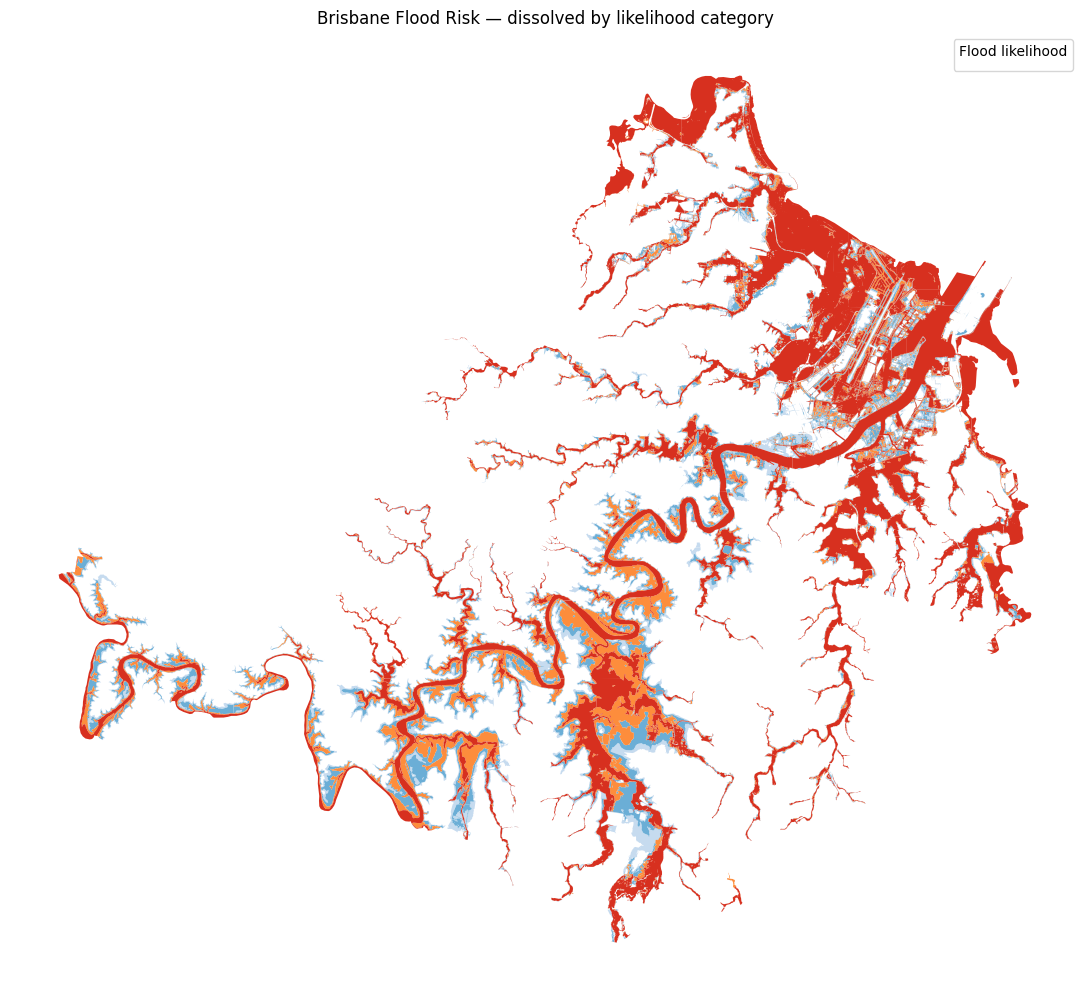

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 11))

# Plot each risk category in a sensible colour, high risk on top
colors = {"Very Low": "#c6dbef", "Low": "#6baed6", "Medium": "#fd8d3c", "High": "#d7301f"}
order = ["Very Low", "Low", "Medium", "High"]

for cat in order:
    flood_dissolved[flood_dissolved["FLOOD_RISK"] == cat].plot(
        ax=ax, color=colors[cat], label=cat, edgecolor="none"
    )

ax.legend(title="Flood likelihood", loc="upper right")
ax.set_title("Brisbane Flood Risk — dissolved by likelihood category")
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [7]:
# Save the cleaned, dissolved flood layer so we never re-run the slow steps
flood_dissolved.to_file("../data/processed/flood_dissolved.gpkg", driver="GPKG")

print("Saved to data/processed/flood_dissolved.gpkg")
print("Features:", len(flood_dissolved))
print("CRS:", flood_dissolved.crs)

Saved to data/processed/flood_dissolved.gpkg
Features: 4
CRS: EPSG:7856


In [9]:
import geopandas as gpd

# List the layers inside the ABS census geopackage (one per geography level)
gpkg_path = "../data/raw/G01_QLD_GDA2020.gpkg"
layers = gpd.list_layers(gpkg_path)

print("Layers in the geopackage:")
print(layers)

Layers in the geopackage:
                  name geometry_type
0   G01_GCCSA_2021_QLD  MultiPolygon
1     G01_UCL_2021_QLD  MultiPolygon
2     G01_SUA_2021_QLD  MultiPolygon
3    G01_SOSR_2021_QLD  MultiPolygon
4     G01_SOS_2021_QLD  MultiPolygon
5     G01_CED_2021_QLD  MultiPolygon
6     G01_LGA_2021_QLD  MultiPolygon
7     G01_POA_2021_QLD  MultiPolygon
8     G01_SA1_2021_QLD  MultiPolygon
9     G01_SA2_2021_QLD  MultiPolygon
10    G01_SA3_2021_QLD  MultiPolygon
11    G01_SA4_2021_QLD  MultiPolygon
12    G01_SAL_2021_QLD  MultiPolygon
13    G01_SED_2021_QLD  MultiPolygon
14    G01_STE_2021_QLD  MultiPolygon
15     G01_RA_2021_QLD  MultiPolygon


In [10]:
# Load the SA2-level census layer (population + dwellings + boundaries)
sa2 = gpd.read_file(gpkg_path, layer="G01_SA2_2021_QLD")

print("Number of SA2 areas in Queensland:", len(sa2))
print("CRS:", sa2.crs)
print("\nAll column names:")
print(sa2.columns.tolist())

Number of SA2 areas in Queensland: 548
CRS: EPSG:7844

All column names:
['SA2_CODE_2021', 'SA2_NAME_2021', 'Tot_P_M', 'Tot_P_F', 'Tot_P_P', 'Age_0_4_yr_M', 'Age_0_4_yr_F', 'Age_0_4_yr_P', 'Age_5_14_yr_M', 'Age_5_14_yr_F', 'Age_5_14_yr_P', 'Age_15_19_yr_M', 'Age_15_19_yr_F', 'Age_15_19_yr_P', 'Age_20_24_yr_M', 'Age_20_24_yr_F', 'Age_20_24_yr_P', 'Age_25_34_yr_M', 'Age_25_34_yr_F', 'Age_25_34_yr_P', 'Age_35_44_yr_M', 'Age_35_44_yr_F', 'Age_35_44_yr_P', 'Age_45_54_yr_M', 'Age_45_54_yr_F', 'Age_45_54_yr_P', 'Age_55_64_yr_M', 'Age_55_64_yr_F', 'Age_55_64_yr_P', 'Age_65_74_yr_M', 'Age_65_74_yr_F', 'Age_65_74_yr_P', 'Age_75_84_yr_M', 'Age_75_84_yr_F', 'Age_75_84_yr_P', 'Age_85ov_M', 'Age_85ov_F', 'Age_85ov_P', 'Counted_Census_Night_home_M', 'Counted_Census_Night_home_F', 'Counted_Census_Night_home_P', 'Count_Census_Nt_Ewhere_Aust_M', 'Count_Census_Nt_Ewhere_Aust_F', 'Count_Census_Nt_Ewhere_Aust_P', 'Indigenous_psns_Aboriginal_M', 'Indigenous_psns_Aboriginal_F', 'Indigenous_psns_Aboriginal_P'

In [11]:
# Load the SA2-level G37 layer (dwellings)
g37 = gpd.read_file("../data/raw/G37_QLD_GDA2020.gpkg", layer="G37_SA2_2021_QLD")

print("G37 SA2 rows:", len(g37))
print("Total columns:", len(g37.columns))
print("\nColumns containing 'Total':")
print([c for c in g37.columns if "Total" in c or "Tot" in c])

G37 SA2 rows: 548
Total columns: 76

Columns containing 'Total':
['O_OR_Total', 'O_MTG_Total', 'R_RE_Agt_Total', 'R_ST_h_auth_Total', 'R_Com_Hp_Total', 'R_Psn_not_in_s_hh_Total', 'R_Ot_landld_typ_Total', 'R_Landld_typ_NS_Total', 'R_Tot_DS_Sep_house', 'R_Tot_DS_SemiD_ro_or_tce_h_th', 'R_Tot_DS_Flat_apart', 'R_Tot_DS_Oth_dwell', 'R_Tot_DS_not_stated', 'R_Tot_Total', 'Oth_ten_type_Total', 'Ten_type_NS_Total', 'Total_DS_Sep_house', 'Total_DS_SemiD_ro_or_tce_h_th', 'Total_DS_Flat_apart', 'Total_DS_Oth_dwell', 'Total_DS_not_stated', 'Total_Total']


In [12]:
# Check the dwelling total column looks sensible
print("Sample of dwelling counts (Total_Total):")
print(g37[["SA2_CODE_2021", "SA2_NAME_2021", "Total_Total"]].head(10))

print("\nQueensland total occupied private dwellings:", g37["Total_Total"].sum())

Sample of dwelling counts (Total_Total):
  SA2_CODE_2021           SA2_NAME_2021  Total_Total
0     301011001         Alexandra Hills         5881
1     301011002       Belmont - Gumdale         2399
2     301011003                Birkdale         5465
3     301011004                Capalaba         6828
4     301011005              Thorneside         1620
5     301011006        Wellington Point         4174
6     301021007               Cleveland         6589
7     301021008                Ormiston         2390
8     301021009             Redland Bay         6022
9     301021011  Sheldon - Mount Cotton         2607

Queensland total occupied private dwellings: 1869510


In [13]:
# Load G01 population layer (we loaded it earlier as 'sa2', but reload cleanly to be safe)
g01 = gpd.read_file(gpkg_path, layer="G01_SA2_2021_QLD")

# Keep only what we need from each table
pop = g01[["SA2_CODE_2021", "SA2_NAME_2021", "Tot_P_P", "geometry"]].copy()
pop = pop.rename(columns={"Tot_P_P": "population"})

dwell = g37[["SA2_CODE_2021", "Total_Total"]].copy()
dwell = dwell.rename(columns={"Total_Total": "dwellings"})

# Join dwellings onto the population table by SA2 code
sa2_data = pop.merge(dwell, on="SA2_CODE_2021", how="left")

print("Joined rows:", len(sa2_data))
print("Columns:", sa2_data.columns.tolist())
print("\nSample:")
print(sa2_data[["SA2_NAME_2021", "population", "dwellings"]].head())
print("\nAny missing dwellings after join?", sa2_data["dwellings"].isna().sum())

Joined rows: 548
Columns: ['SA2_CODE_2021', 'SA2_NAME_2021', 'population', 'geometry', 'dwellings']

Sample:
       SA2_NAME_2021  population  dwellings
0    Alexandra Hills       16574       5881
1  Belmont - Gumdale        7550       2399
2           Birkdale       15230       5465
3           Capalaba       18254       6828
4         Thorneside        3877       1620

Any missing dwellings after join? 0


In [14]:
# The SA2 code is hierarchical. Let's see its structure and look for a Brisbane identifier.
# First, check the code format
print("Sample SA2 codes:")
print(sa2_data["SA2_CODE_2021"].head(10).tolist())

# The GCCSA (Greater Capital City) is encoded in the SA2 structure.
# Greater Brisbane's GCCSA code is '3GBRI'. SA2 codes starting with '3' are QLD,
# but we need the GCCSA level. Let's load the GCCSA layer to get Brisbane's SA2s properly.
gccsa = gpd.read_file(gpkg_path, layer="G01_GCCSA_2021_QLD")
print("\nGCCSA regions in QLD:")
print(gccsa[["GCCSA_CODE_2021", "GCCSA_NAME_2021"]] if "GCCSA_NAME_2021" in gccsa.columns else gccsa.columns.tolist())

Sample SA2 codes:
['301011001', '301011002', '301011003', '301011004', '301011005', '301011006', '301021007', '301021008', '301021009', '301021011']

GCCSA regions in QLD:
  GCCSA_CODE_2021                        GCCSA_NAME_2021
0           3GBRI                       Greater Brisbane
1           3RQLD                            Rest of Qld
2           39499                 No usual address (Qld)
3           39799  Migratory - Offshore - Shipping (Qld)


In [15]:
# Greater Brisbane SA2s: ABS SA2 codes are hierarchical.
# The first digit (3) = Queensland. We need which SA2s sit under GCCSA '3GBRI'.
# Check if there's a code pattern by comparing Brisbane-known suburbs.

# The reliable way: SA2 codes within Greater Brisbane fall in specific SA4 ranges.
# Let's look at the unique 3-digit prefixes (SA3-ish level) to understand the range
sa2_data["sa4_prefix"] = sa2_data["SA2_CODE_2021"].str[:3]
print("Unique SA4 prefixes and a sample suburb from each:")
for prefix in sorted(sa2_data["sa4_prefix"].unique()):
    sample = sa2_data[sa2_data["sa4_prefix"] == prefix]["SA2_NAME_2021"].iloc[0]
    count = (sa2_data["sa4_prefix"] == prefix).sum()
    print(f"  {prefix}: {count} SA2s — e.g. {sample}")

Unique SA4 prefixes and a sample suburb from each:
  301: 22 SA2s — e.g. Alexandra Hills
  302: 25 SA2s — e.g. Bald Hills
  303: 34 SA2s — e.g. Camp Hill
  304: 24 SA2s — e.g. Jindalee - Mount Ommaney
  305: 33 SA2s — e.g. Brisbane City
  306: 33 SA2s — e.g. Brinsmead
  307: 19 SA2s — e.g. Balonne
  308: 34 SA2s — e.g. Central Highlands - East
  309: 54 SA2s — e.g. Broadbeach Waters
  310: 36 SA2s — e.g. Darra - Sumner
  311: 35 SA2s — e.g. Beaudesert
  312: 25 SA2s — e.g. Bowen
  313: 22 SA2s — e.g. Beachmere - Sandstone Point
  314: 15 SA2s — e.g. Albany Creek
  315: 18 SA2s — e.g. Aurukun
  316: 34 SA2s — e.g. Buderim - North
  317: 15 SA2s — e.g. Cambooya - Wyreema
  318: 33 SA2s — e.g. Ayr
  319: 35 SA2s — e.g. Ashfield - Kepnock
  397: 1 SA2s — e.g. Migratory - Offshore - Shipping (Qld)
  399: 1 SA2s — e.g. No usual address (Qld)


In [16]:
# Get just the Greater Brisbane GCCSA polygon
brisbane_poly = gccsa[gccsa["GCCSA_CODE_2021"] == "3GBRI"].copy()
print("Greater Brisbane polygon CRS:", brisbane_poly.crs)
print("SA2 data CRS:", sa2_data.crs)

# Make sure both are in the same CRS before spatial work
brisbane_poly = brisbane_poly.to_crs(sa2_data.crs)

# Use the SA2 centroids to decide membership (cleaner than edge overlaps)
sa2_centroids = sa2_data.copy()
sa2_centroids["geometry"] = sa2_centroids.geometry.centroid

# Spatial join: keep SA2s whose centroid falls inside Greater Brisbane
brisbane_sa2_codes = gpd.sjoin(
    sa2_centroids, brisbane_poly, predicate="within", how="inner"
)["SA2_CODE_2021"]

# Filter the full SA2 data (with real polygons) to those codes
brisbane = sa2_data[sa2_data["SA2_CODE_2021"].isin(brisbane_sa2_codes)].copy()

print("\nGreater Brisbane SA2s:", len(brisbane))
print("Total population:", brisbane["population"].sum())
print("Total dwellings:", brisbane["dwellings"].sum())
print("\nSample suburbs:")
print(brisbane[["SA2_NAME_2021", "population", "dwellings"]].head(10))

Greater Brisbane polygon CRS: EPSG:7844
SA2 data CRS: EPSG:7844


/var/folders/nc/kql9kdyn21g70cyyl5qh4_400000gn/T/ipykernel_46392/2154214596.py:11: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  sa2_centroids["geometry"] = sa2_centroids.geometry.centroid



Greater Brisbane SA2s: 243
Total population: 2507579
Total dwellings: 903724

Sample suburbs:
            SA2_NAME_2021  population  dwellings
0         Alexandra Hills       16574       5881
1       Belmont - Gumdale        7550       2399
2                Birkdale       15230       5465
3                Capalaba       18254       6828
4              Thorneside        3877       1620
5        Wellington Point       11893       4174
6               Cleveland       15851       6589
7                Ormiston        6379       2390
8             Redland Bay       17765       6022
9  Sheldon - Mount Cotton        8357       2607


In [17]:
# Reproject to metric CRS (matches the flood layer's EPSG:7856) and save
brisbane_clean = brisbane.to_crs("EPSG:7856")

# Drop the helper column if it exists
if "sa4_prefix" in brisbane_clean.columns:
    brisbane_clean = brisbane_clean.drop(columns="sa4_prefix")

brisbane_clean.to_file("../data/processed/brisbane_sa2.gpkg", driver="GPKG")

print("Saved Greater Brisbane study area:")
print("  SA2s:", len(brisbane_clean))
print("  CRS:", brisbane_clean.crs)
print("  Columns:", brisbane_clean.columns.tolist())
print("  Population:", brisbane_clean["population"].sum())
print("  Dwellings:", brisbane_clean["dwellings"].sum())

Saved Greater Brisbane study area:
  SA2s: 243
  CRS: EPSG:7856
  Columns: ['SA2_CODE_2021', 'SA2_NAME_2021', 'population', 'geometry', 'dwellings']
  Population: 2507579
  Dwellings: 903724


In [18]:
# Reload the cleaned flood layer (in case it dropped from memory)
flood_dissolved = gpd.read_file("../data/processed/flood_dissolved.gpkg")
print("Flood layer reloaded:")
print("  Features:", len(flood_dissolved))
print("  CRS:", flood_dissolved.crs)
print("  Categories:", flood_dissolved["FLOOD_RISK"].tolist())

# Confirm Brisbane is still in memory and matches CRS
print("\nBrisbane SA2s:", len(brisbane_clean), "| CRS:", brisbane_clean.crs)
print("CRS match:", flood_dissolved.crs == brisbane_clean.crs)

Flood layer reloaded:
  Features: 4
  CRS: EPSG:7856
  Categories: ['High', 'Low', 'Medium', 'Very Low']

Brisbane SA2s: 243 | CRS: EPSG:7856
CRS match: True


In [19]:
# Record each suburb's full area BEFORE intersecting (needed for the fraction)
brisbane_clean["sa2_area"] = brisbane_clean.geometry.area

# Intersect suburbs with flood categories.
# overlay(how="intersection") cuts the suburbs by the flood polygons,
# producing fragments tagged with BOTH the suburb and the flood level.
intersect = gpd.overlay(
    brisbane_clean,
    flood_dissolved,
    how="intersection",
    keep_geom_type=True
)

# Area of each intersected fragment
intersect["frag_area"] = intersect.geometry.area

# Fraction of the suburb that this flooded fragment represents
intersect["area_frac"] = intersect["frag_area"] / intersect["sa2_area"]

# Estimate exposed population and dwellings for each fragment
intersect["pop_exposed"] = intersect["population"] * intersect["area_frac"]
intersect["dwel_exposed"] = intersect["dwellings"] * intersect["area_frac"]

print("Intersection fragments:", len(intersect))
print("\nExposure by flood category (all of Greater Brisbane):")
summary = intersect.groupby("FLOOD_RISK").agg(
    pop_exposed=("pop_exposed", "sum"),
    dwel_exposed=("dwel_exposed", "sum")
).round(0)
print(summary)

Intersection fragments: 559

Exposure by flood category (all of Greater Brisbane):
            pop_exposed  dwel_exposed
FLOOD_RISK                           
High           117705.0       44254.0
Low             66342.0       26074.0
Medium          69847.0       26682.0
Very Low        48426.0       18913.0


In [20]:
# Which suburbs drive the "High" flood exposure? Top 15 by exposed population.
high = intersect[intersect["FLOOD_RISK"] == "High"].copy()
high_by_sa2 = high.groupby("SA2_NAME_2021").agg(
    pop_exposed=("pop_exposed", "sum"),
    dwel_exposed=("dwel_exposed", "sum"),
    area_frac=("area_frac", "sum")
).sort_values("pop_exposed", ascending=False).round(2)

print("Top 15 suburbs by HIGH flood-risk population exposure:")
print(high_by_sa2.head(15))

Top 15 suburbs by HIGH flood-risk population exposure:
                        pop_exposed  dwel_exposed  area_frac
SA2_NAME_2021                                               
Wynnum West - Hemmant       4895.52       1805.42       0.31
Nudgee - Banyo              4781.56       1705.39       0.44
Bald Hills                  4441.12       1534.47       0.57
Boondall                    4227.87       1548.66       0.44
Tingalpa                    3721.00       1404.44       0.42
Newstead - Bowen Hills      3377.47       1770.66       0.19
Brighton (Qld)              2884.11       1096.76       0.30
Taigum - Fitzgibbon         2634.53       1043.39       0.19
Carindale                   2458.30        852.15       0.15
Windsor                     2426.66       1016.23       0.30
Pallara - Willawong         2343.33        710.80       0.23
Rocklea - Acacia Ridge      2330.14        837.66       0.24
Cannon Hill                 2164.53        836.14       0.31
Oxley (Qld)                 20

In [21]:
# Full per-suburb exposure summary across all flood categories
suburb_exposure = intersect.groupby(["SA2_CODE_2021", "SA2_NAME_2021", "FLOOD_RISK"]).agg(
    pop_exposed=("pop_exposed", "sum"),
    dwel_exposed=("dwel_exposed", "sum")
).reset_index()

# Pivot so each suburb is one row, with a column per flood level (population)
pop_pivot = suburb_exposure.pivot_table(
    index=["SA2_CODE_2021", "SA2_NAME_2021"],
    columns="FLOOD_RISK",
    values="pop_exposed",
    fill_value=0
).round(0)

# Add a total-exposed column and a high+medium "priority" column
pop_pivot["Total_Exposed"] = pop_pivot.sum(axis=1)
pop_pivot["High_Med_Exposed"] = pop_pivot.get("High", 0) + pop_pivot.get("Medium", 0)

# Rank suburbs by high+medium exposure (the planning priority)
ranking = pop_pivot.sort_values("High_Med_Exposed", ascending=False).reset_index()

print("Top 15 Brisbane suburbs by HIGH+MEDIUM flood exposure (population):")
print(ranking[["SA2_NAME_2021", "High", "Medium", "Low", "Very Low", "High_Med_Exposed"]].head(15).to_string(index=False))

Top 15 Brisbane suburbs by HIGH+MEDIUM flood exposure (population):
         SA2_NAME_2021   High  Medium    Low  Very Low  High_Med_Exposed
Newstead - Bowen Hills 3377.0  2917.0 3170.0    1405.0            6294.0
 Wynnum West - Hemmant 4896.0  1239.0 1398.0     772.0            6135.0
        Nudgee - Banyo 4782.0   261.0  419.0     248.0            5043.0
              West End  544.0  4458.0 2659.0    1720.0            5002.0
              Boondall 4228.0   431.0  407.0     363.0            4659.0
Rocklea - Acacia Ridge 2330.0  2289.0 1174.0     479.0            4619.0
            Bald Hills 4441.0   162.0   70.0      93.0            4603.0
              Tingalpa 3721.0   391.0  261.0     330.0            4112.0
  Chelmer - Graceville  186.0  3814.0 1603.0    1277.0            4000.0
        South Brisbane  262.0  3730.0 3191.0    1197.0            3992.0
         Indooroopilly 1368.0  2624.0 1448.0     904.0            3992.0
              St Lucia  125.0  3467.0 1444.0    1094.0  

In [22]:
import os
os.makedirs("../outputs", exist_ok=True)

# 1. Save the per-suburb exposure ranking as CSV (for the README + reference)
ranking_out = ranking[["SA2_CODE_2021", "SA2_NAME_2021", "High", "Medium", "Low", "Very Low", "High_Med_Exposed", "Total_Exposed"]]
ranking_out.to_csv("../outputs/brisbane_flood_exposure_by_suburb.csv", index=False)

# 2. Save the category summary
summary.to_csv("../outputs/flood_exposure_summary.csv")

# 3. Save the suburb-level exposure WITH geometry as a GeoPackage — this is what
#    we'll publish to ArcGIS Online for the dashboard.
#    Merge the High+Med priority back onto the suburb polygons.
brisbane_dash = brisbane_clean.merge(
    ranking[["SA2_CODE_2021", "High", "Medium", "Low", "Very Low", "High_Med_Exposed", "Total_Exposed"]],
    on="SA2_CODE_2021",
    how="left"
)
# Fill suburbs with no flood exposure as 0
for col in ["High", "Medium", "Low", "Very Low", "High_Med_Exposed", "Total_Exposed"]:
    brisbane_dash[col] = brisbane_dash[col].fillna(0)

brisbane_dash.to_file("../data/processed/brisbane_flood_dashboard.gpkg", driver="GPKG")

print("Saved outputs:")
print("  outputs/brisbane_flood_exposure_by_suburb.csv")
print("  outputs/flood_exposure_summary.csv")
print("  data/processed/brisbane_flood_dashboard.gpkg  <- publish this to AGOL")
print("\nDashboard layer rows:", len(brisbane_dash))
print("Suburbs with any flood exposure:", (brisbane_dash["Total_Exposed"] > 0).sum())

Saved outputs:
  outputs/brisbane_flood_exposure_by_suburb.csv
  outputs/flood_exposure_summary.csv
  data/processed/brisbane_flood_dashboard.gpkg  <- publish this to AGOL

Dashboard layer rows: 243
Suburbs with any flood exposure: 140


In [23]:
import os
os.makedirs("../outputs/agol_upload", exist_ok=True)

# Export the dashboard layer as a zipped shapefile (AGOL-friendly).
# AGOL prefers WGS84 (EPSG:4326) for upload, so reproject.
brisbane_dash_wgs = brisbane_dash.to_crs("EPSG:4326")

# Shapefile column names are limited to 10 characters — rename the long ones
brisbane_dash_wgs = brisbane_dash_wgs.rename(columns={
    "SA2_NAME_2021": "suburb",
    "SA2_CODE_2021": "sa2_code",
    "population": "pop",
    "dwellings": "dwel",
    "High_Med_Exposed": "high_med",
    "Total_Exposed": "tot_exp",
    "Very Low": "VeryLow"
})

shp_path = "../outputs/agol_upload/brisbane_flood_exposure.shp"
brisbane_dash_wgs.to_file(shp_path)

# Zip the shapefile components (AGOL needs them zipped together)
import shutil
shutil.make_archive("../outputs/agol_upload/brisbane_flood_exposure", "zip", "../outputs/agol_upload")

print("Exported and zipped for AGOL upload:")
print("  ../outputs/agol_upload/brisbane_flood_exposure.zip")
print("\nColumns in upload:", brisbane_dash_wgs.columns.tolist())

Exported and zipped for AGOL upload:
  ../outputs/agol_upload/brisbane_flood_exposure.zip

Columns in upload: ['sa2_code', 'suburb', 'pop', 'geometry', 'dwel', 'sa2_area', 'High', 'Medium', 'Low', 'VeryLow', 'high_med', 'tot_exp']


In [24]:
import folium
import branca.colormap as cm

print("folium version:", folium.__version__)

brisbane_map = gpd.read_file("../data/processed/brisbane_flood_dashboard.gpkg").to_crs("EPSG:4326")
print("Suburbs loaded:", len(brisbane_map))
print("Columns:", brisbane_map.columns.tolist())
print("High+Med range:", round(brisbane_map["High_Med_Exposed"].min()), "to", round(brisbane_map["High_Med_Exposed"].max()))

folium version: 0.20.0
Suburbs loaded: 243
Columns: ['SA2_CODE_2021', 'SA2_NAME_2021', 'population', 'dwellings', 'sa2_area', 'High', 'Medium', 'Low', 'Very Low', 'High_Med_Exposed', 'Total_Exposed', 'geometry']
High+Med range: 0 to 6294


In [25]:
# Build the interactive Brisbane flood-exposure map
# Center on Brisbane
m = folium.Map(location=[-27.47, 153.02], zoom_start=10, tiles="cartodbpositron")

# Color scale based on High+Medium population exposed (the planning priority)
max_exp = brisbane_map["High_Med_Exposed"].max()
colormap = cm.LinearColormap(
    colors=["#ffffcc", "#fd8d3c", "#e31a1c", "#800026"],
    vmin=0, vmax=max_exp,
    caption="People exposed to High + Medium flood risk"
)

# Style function: color each suburb by its High+Med exposure
def style_fn(feature):
    val = feature["properties"]["High_Med_Exposed"]
    return {
        "fillColor": colormap(val) if val and val > 0 else "#f0f0f0",
        "color": "white",
        "weight": 0.5,
        "fillOpacity": 0.75,
    }

def highlight_fn(feature):
    return {"weight": 2, "color": "#333", "fillOpacity": 0.9}

# Tooltip (hover) and popup (click) fields
folium.GeoJson(
    brisbane_map,
    style_function=style_fn,
    highlight_function=highlight_fn,
    tooltip=folium.GeoJsonTooltip(
        fields=["SA2_NAME_2021", "High_Med_Exposed"],
        aliases=["Suburb:", "High+Med exposed:"],
        localize=True
    ),
    popup=folium.GeoJsonPopup(
        fields=["SA2_NAME_2021", "population", "dwellings", "High", "Medium", "Low", "Very Low"],
        aliases=["Suburb", "Total population", "Total dwellings",
                 "High-risk pop", "Medium-risk pop", "Low-risk pop", "Very-low-risk pop"],
        localize=True
    ),
).add_to(m)

colormap.add_to(m)

# Save it
import os
os.makedirs("../outputs", exist_ok=True)
m.save("../outputs/brisbane_flood_exposure_map.html")
print("Map saved to ../outputs/brisbane_flood_exposure_map.html")
m

Map saved to ../outputs/brisbane_flood_exposure_map.html


In [26]:
# Export a Tableau-friendly CSV: one row per suburb, centroid lat/long + exposure numbers
# Reproject to a metric CRS for accurate centroids, compute them, then convert centroids to lat/long

# Work from the dashboard layer (metric CRS 7856)
tab = gpd.read_file("../data/processed/brisbane_flood_dashboard.gpkg")  # EPSG:7856

# Compute centroids in the metric CRS (accurate), then reproject those points to lat/long
centroids = tab.geometry.centroid.to_crs("EPSG:4326")
tab["longitude"] = centroids.x
tab["latitude"] = centroids.y

# Build a clean flat table (no geometry) for Tableau
tableau_df = tab[[
    "SA2_NAME_2021", "SA2_CODE_2021",
    "latitude", "longitude",
    "population", "dwellings",
    "High", "Medium", "Low", "Very Low",
    "High_Med_Exposed", "Total_Exposed"
]].copy()

# Friendlier column names for Tableau's field list
tableau_df = tableau_df.rename(columns={
    "SA2_NAME_2021": "Suburb",
    "SA2_CODE_2021": "SA2_Code",
    "population": "Population",
    "dwellings": "Dwellings",
    "High": "Pop_High_Risk",
    "Medium": "Pop_Medium_Risk",
    "Low": "Pop_Low_Risk",
    "Very Low": "Pop_VeryLow_Risk",
    "High_Med_Exposed": "Pop_High_Med_Exposed",
    "Total_Exposed": "Pop_Total_Exposed"
})

# Round the exposure estimates to whole people (no fake precision)
for col in ["Pop_High_Risk", "Pop_Medium_Risk", "Pop_Low_Risk", "Pop_VeryLow_Risk",
            "Pop_High_Med_Exposed", "Pop_Total_Exposed"]:
    tableau_df[col] = tableau_df[col].round(0).astype(int)

tableau_df.to_csv("../outputs/brisbane_flood_exposure_tableau.csv", index=False)

print("Saved Tableau CSV:", len(tableau_df), "suburbs")
print("Columns:", tableau_df.columns.tolist())
print("\nTop 5 by High+Med exposure:")
print(tableau_df.nlargest(5, "Pop_High_Med_Exposed")[["Suburb", "Population", "Pop_High_Med_Exposed"]].to_string(index=False))

Saved Tableau CSV: 243 suburbs
Columns: ['Suburb', 'SA2_Code', 'latitude', 'longitude', 'Population', 'Dwellings', 'Pop_High_Risk', 'Pop_Medium_Risk', 'Pop_Low_Risk', 'Pop_VeryLow_Risk', 'Pop_High_Med_Exposed', 'Pop_Total_Exposed']

Top 5 by High+Med exposure:
                Suburb  Population  Pop_High_Med_Exposed
Newstead - Bowen Hills       18016                  6294
 Wynnum West - Hemmant       15681                  6135
        Nudgee - Banyo       10789                  5043
              West End       14953                  5002
              Boondall        9596                  4659


In [28]:
import pandas as pd

# Dwelling exposure per suburb per flood category (from the intersect we built earlier)
dwel_by_cat = intersect.pivot_table(
    index="SA2_CODE_2021", columns="FLOOD_RISK",
    values="dwel_exposed", aggfunc="sum", fill_value=0
)
dwel_by_cat["dwel_total_exposed"] = dwel_by_cat.sum(axis=1)
dwel_by_cat["dwel_high_med_exposed"] = dwel_by_cat.get("High", 0) + dwel_by_cat.get("Medium", 0)
dwel_by_cat = dwel_by_cat.reset_index()[["SA2_CODE_2021", "dwel_total_exposed", "dwel_high_med_exposed"]]

# Load existing tableau CSV; force both join keys to string to avoid type mismatch
tdf = pd.read_csv("../outputs/brisbane_flood_exposure_tableau.csv")
tdf["SA2_Code"] = tdf["SA2_Code"].astype(str)
dwel_by_cat["SA2_CODE_2021"] = dwel_by_cat["SA2_CODE_2021"].astype(str)

tdf = tdf.merge(dwel_by_cat, left_on="SA2_Code", right_on="SA2_CODE_2021", how="left").drop(columns="SA2_CODE_2021")
tdf[["dwel_total_exposed", "dwel_high_med_exposed"]] = tdf[["dwel_total_exposed", "dwel_high_med_exposed"]].fillna(0).round(0).astype(int)

tdf.to_csv("../outputs/brisbane_flood_exposure_tableau.csv", index=False)
print("Re-exported with dwelling exposure.")
print("Total dwellings exposed:", tdf["dwel_total_exposed"].sum())
print("Columns:", tdf.columns.tolist())

Re-exported with dwelling exposure.
Total dwellings exposed: 115925
Columns: ['Suburb', 'SA2_Code', 'latitude', 'longitude', 'Population', 'Dwellings', 'Pop_High_Risk', 'Pop_Medium_Risk', 'Pop_Low_Risk', 'Pop_VeryLow_Risk', 'Pop_High_Med_Exposed', 'Pop_Total_Exposed', 'dwel_total_exposed', 'dwel_high_med_exposed']
